In [29]:
pip install -r ../requirements.txt

     ---------------------------------------- 0.0/7.8 MB ? eta -:--:--
     ---------------------------------------  7.6/7.8 MB 103.7 MB/s eta 0:00:01
     ---------------------------------------- 7.8/7.8 MB 35.5 MB/s  0:00:00
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44340 sha256=21073cd37627ed99fe5a70fa77b86fab3468a9d565342bda460be9bd143ca586
  Stored in directory: c:\users\yacinou\appdata\local\pip\cache\wheels\b9\1c\2d\281a1509651a08cada4dd95a63ee095f00f234b6a96d61c089
Successfully built grad-cam

   -------------------- ------------------- 1/2 [grad-cam]
   ---------------------------------------- 2/2 [grad-cam]

Note: you 

In [ ]:
# Importation des bibliothèques nécessaires
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.metrics import f1_score,accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, log_loss
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder

from wordcloud import WordCloud
import langdetect
from langdetect import detect, detect_langs, DetectorFactory, LangDetectException
import nltk
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer

import xgboost as xgb
from xgboost import XGBClassifier

from lime.lime_text import LimeTextExplainer

# Téléchargement des stopwords si ce n'est pas déjà fait
nltk.download('stopwords')

import warnings
warnings.filterwarnings("ignore")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Yacinou\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [6]:
# Chargement initial des données
X_train_init = pd.read_csv("../data/X_train_update.csv", nrows=50000)
y_train_init = pd.read_csv("../data/Y_train_CVw08PX.csv", nrows=50000)
X_test_init = pd.read_csv("../data/X_test_update.csv", nrows=50000)

# Affichage des informations sur les datasets
print(f"Info X_train_init : {X_train_init.info()}")
print(f"\nInfo Y_train_init : {y_train_init.info()}")
print(f"\nInfo X_test_init : {X_test_init.info()}")

# Affichage des tailles des datasets
print(f"\nTaille X_train_init : {X_train_init.shape}")
print(f"\nTaille Y_train_init : {y_train_init.shape}")
print(f"\nTaille X_test_init : {X_test_init.shape}")

# Affichage du nombre de classes dans la variable cible
print(y_train_init['prdtypecode'].nunique())  # 27 classes

# Merge données d'entrainement dans le dataframe "full_data"
full_data = pd.merge(X_train_init, y_train_init, left_index=True, right_index=True)

# Suppression de la colonne Unnamed: 0_y qui est une colonne d'index inutile
full_data = full_data.drop(['Unnamed: 0_y'], axis=1)

# Renomage de la colonne Unnamed: 0_x en id et mise en index de cette colonne
full_data.rename(columns={'Unnamed: 0_x': 'id'}, inplace=True)  
full_data.set_index(['id'], inplace=True)

#Longueur des textes
full_data['len_designation'] = (full_data['designation'].astype(str).apply(len))
full_data['len_description'] = (full_data['description'].astype(str).apply(len))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Unnamed: 0   50000 non-null  int64 
 1   designation  50000 non-null  object
 2   description  32550 non-null  object
 3   productid    50000 non-null  int64 
 4   imageid      50000 non-null  int64 
dtypes: int64(3), object(2)
memory usage: 1.9+ MB
Info X_train_init : None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Unnamed: 0   50000 non-null  int64
 1   prdtypecode  50000 non-null  int64
dtypes: int64(2)
memory usage: 781.4 KB

Info Y_train_init : None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13812 entries, 0 to 13811
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   U

In [7]:
#Fonction de nettoyage du texte simple pour les colonnes de texte
import re

def clean_text(text):
    """
    Nettoyage de base du texte : suppression des balises HTML, des URLs, conversion en minuscules, suppression de la ponctuation et des chiffres.
    """
    if pd.isnull(text):
        return ""

    # Suppression des balises HTML
    text = re.sub(r'<.*?>', '', text)

    # Remplacement des <br /> par un espace
    text = text.replace(r'<br />', ' ')

    # Remplacement des référence de caractère HTML
    text = text.replace(r'&amp;', '&')
    text = text.replace(r'&nbsp;', ' ')
    text = text.replace(r'&lt', '<')
    text = text.replace(r'&gt', '>')
    text = text.replace(r'&quot', '"')
    text = text.replace(r'&#39', "'")
    text = text.replace(r'&eacute', 'e')
    text = text.replace(r'&egrave', 'e')
    text = text.replace(r'&ecirc', 'e')

    # Suppression des URLs et des liens  
    text = re.sub(r"http\S+|www\.\S+", " ", text)

    # Conversion en minuscules
    text = text.lower()

    # Suppression des espaces supplémentaires
    text = re.sub(r'\s+', ' ', text).strip()

    # Suppression de la ponctuation
    text = re.sub(r'[^\w\s]', '', text)

    # Suppression des chiffres
    text = re.sub(r'\d+', '', text)

    return text

In [8]:
# Nettoyage du texte
full_data['clean_designation'] = full_data['designation'].apply(clean_text)
full_data['clean_description'] = full_data['description'].apply(clean_text)

# Vérification de doublon dans les désignations et descriptions nettoyées
duplicate_designation = full_data['clean_designation'].duplicated().sum()
duplicate_description = full_data['clean_description'].duplicated().sum()

# Concaténation des désignations et descriptions nettoyées pour l'analyse de texte
full_data['text'] = full_data['clean_designation'] + ' ' + full_data['clean_description']

# Création d'un nouveau dataframe pour l'analyse de texte
clean_data = full_data.drop(columns=['designation', 'description', 'productid', 'imageid','clean_designation','clean_description','len_description', 'len_designation',], axis=1)

In [9]:
# Chargement des stopwords français et anglais
stop_fr = set(stopwords.words("french"))  # Stopwords français
stop_en = set(stopwords.words("english"))  # Stopwords anglais
stop_all = stop_fr.union(stop_en)  # Union des deux listes

# "Générique" est un terme générique et non discriminant pour différencier les classes de produits, on l'ajoute à la liste des stopwords
stop_all.add("générique")

def delete_stopwords(text):
    """
    Suppression des mots vides (stopwords)
    """
    return " ".join([w for w in text.split() if w not in stop_all and len(w) > 1])  # Garde mots > 1 caractère

# Application de la suppression des stopwords
clean_data["text_nostop"] = clean_data['text'].apply(delete_stopwords)  # Texte sans stopwords

# Stemming français (réduction des mots à leur racine)
stemmer = SnowballStemmer("french")
def stem_text(text):
    """
    Application du stemming sur chaque mot (réduction à la racine)
    """
    return " ".join([stemmer.stem(w) for w in text.split()])  # Stemming mot par mot

# Application du stemming
clean_data["text_stem"] = clean_data["text_nostop"].apply(stem_text)  # Texte stemmé final

# Fin du processing textuel ci-dessus
# Début de la vectorisation + application des modèles ci-dessous

In [10]:
# Préparation des données pour l'analyse de texte
X = clean_data['text']
y = clean_data['prdtypecode']

# Encodage des labels de la variable cible avec LabelEncoder
le = LabelEncoder()
y_enc = le.fit_transform(y)

# Création des ensembles d'entraînement et de test pour l'analyse de texte (20% pour le test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)

# Initialisation de TfidfVectorizer avec des paramètres pour limiter le nombre de features et les n-grams
tfidf = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

# Vectorisation du texte avec TF-IDF
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [ ]:
from sklearn.naive_bayes import MultinomialNB

# Création du modèle Naive Bayes Multinomial basique
nb_clf = MultinomialNB(alpha=1.0)

# Entraînement du modèle Naive Bayes Multinomial 
nb_clf.fit(X_train_tfidf, y_train)

# Prédiction sur l'ensemble de test
y_pred_nb = nb_clf.predict(X_test_tfidf)

# Calcul F1-score pondéré
f1_nb = f1_score(y_test, y_pred_nb, average="weighted")
print("F1-score du modèle Naive Bayes:", f1_nb)

F1-score du modèle Naive Bayes: 0.6719137379034676


              precision    recall  f1-score   support

          10       0.68      0.21      0.32       359
          40       0.79      0.44      0.56       294
          50       0.76      0.60      0.67       199
          60       0.96      0.80      0.88        96
        1140       0.74      0.67      0.70       317
        1160       0.84      0.92      0.88       449
        1180       0.93      0.15      0.26        91
        1280       0.52      0.61      0.56       571
        1281       0.89      0.25      0.39       239
        1300       0.71      0.94      0.81       595
        1301       1.00      0.47      0.64        91
        1302       0.86      0.40      0.55       295
        1320       0.90      0.48      0.62       392
        1560       0.58      0.76      0.66       611
        1920       0.83      0.85      0.84       516
        1940       1.00      0.22      0.36        88
        2060       0.51      0.80      0.63       599
        2220       1.00    

<Figure size 2400x2000 with 0 Axes>

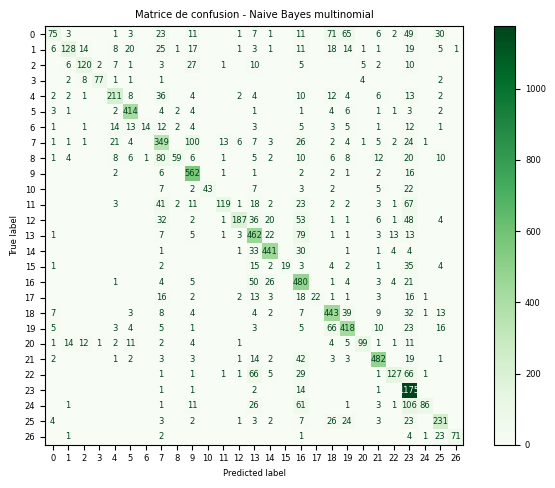

In [13]:
# Affichage du rapport de classification
print(classification_report(y_test, y_pred_nb, target_names=le.classes_.astype(str)))

# Affichage de la matrice de confusion
cm_nb = confusion_matrix(y_test, y_pred_nb)
plt.figure(figsize=(24,20))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_nb)
disp.plot(cmap="Greens", values_format="d")

for text in disp.text_.flatten():
    if text.get_text() == "0":
        text.set_text("") # Supprime les annotations "0" pour une meilleure lisibilité

plt.title("Matrice de confusion - Naive Bayes multinomial")
plt.rcParams['font.size'] = 4
plt.savefig("../reports/figures/viz_txt_NB_confusion.png", dpi=150, bbox_inches="tight")
plt.tight_layout()
plt.show()

In [20]:
# Recherche d'hyperparamètres pour le modèle Naive Bayes Multinomial avec GridSearchCV
param_grid_nb = {
    "alpha": [0.1, 0.5, 1.0, 2.0] # Valeurs d'alpha à tester pour le lissage de Laplace
}
gs_nb = GridSearchCV(
    MultinomialNB(), # Modèle Naive Bayes Multinomial
    param_grid_nb,
    scoring="f1_weighted", # Utilisation du F1-score pondéré pour évaluer les performances du modèle
    cv=3, # Validation croisée à 3 blocs pour une évaluation robuste
    n_jobs=-1 # Utilisation de tous les cœurs disponibles pour accélérer la recherche d'hyperparamètres
)

# Entraînement optimisé
gs_nb.fit(X_train_tfidf, y_train)  # Fit avec optimisation

# Prédiction avec le modèle optimisé
y_pred_nb_opt = gs_nb.predict(X_test_tfidf)


In [21]:
# Rapport de classification avec les meilleurs hyperparamètres trouvés par GridSearchCV
print(classification_report(
    y_test, y_pred_nb_opt, 
    target_names=le.classes_.astype(str),
    digits=4
))

# Prédiction des probabilités pour le calcul de la cross-entropy (log loss)
y_proba = gs_nb.predict_proba(X_test_tfidf) 
# Calcul de la cross-entropy (log loss) pour évaluer la qualité des probabilités prédites par le modèle optimisé
ce_gsnb = log_loss(y_test, y_proba) 
print("Cross-entropy du modèle Naive Bayes optimisé:", ce_gsnb)

# Meilleurs résultats
print(f"Meilleurs paramètres NB: {gs_nb.best_params_}")
print(f"Meilleur F1 CV: {gs_nb.best_score_:.4f}")

# Test final optimisé
f1_nb_opt = f1_score(y_test, y_pred_nb_opt, average="weighted")
print(f"F1 test optimisé: {f1_nb_opt:.4f}")

# Matrice de confusion
cm_nb = confusion_matrix(y_test, y_pred_nb)

              precision    recall  f1-score   support

          10     0.6374    0.3231    0.4288       359
          40     0.7290    0.5306    0.6142       294
          50     0.7929    0.7889    0.7909       199
          60     0.9294    0.8229    0.8729        96
        1140     0.6507    0.7697    0.7052       317
        1160     0.8501    0.9220    0.8846       449
        1180     0.8261    0.4176    0.5547        91
        1280     0.5851    0.5657    0.5752       571
        1281     0.6690    0.4059    0.5052       239
        1300     0.7811    0.9294    0.8488       595
        1301     0.9595    0.7802    0.8606        91
        1302     0.7765    0.6712    0.7200       295
        1320     0.8052    0.7066    0.7527       392
        1560     0.7136    0.7627    0.7373       611
        1920     0.8817    0.8663    0.8739       516
        1940     0.9853    0.7614    0.8590        88
        2060     0.6724    0.7780    0.7214       599
        2220     0.9828    

<Figure size 2400x2000 with 0 Axes>

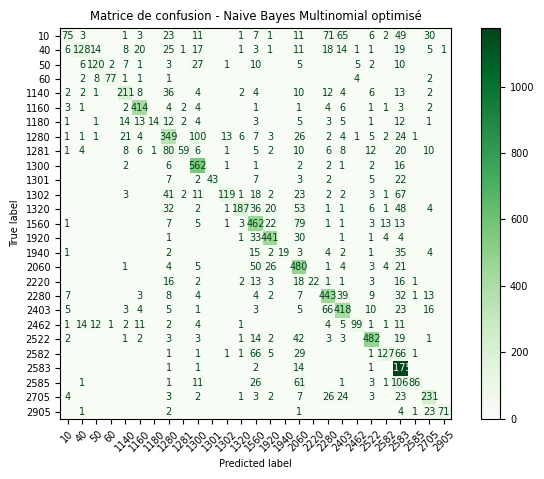

In [27]:
plt.figure(figsize=(24,20))
disp_nb = ConfusionMatrixDisplay(confusion_matrix=cm_nb, display_labels=le.classes_.astype(str))
disp_nb.plot(cmap="Greens", values_format="d", xticks_rotation=45)

for text in disp_nb.text_.flatten():
    if text.get_text() == "0":
        text.set_text("") # Supprime les annotations "0" pour une meilleure lisibilité

plt.title("Matrice de confusion - Naive Bayes Multinomial optimisé")
plt.tight_layout()
plt.savefig("../reports/figures/viz_txt_NBOpt_confusion.png", dpi=150, bbox_inches="tight")
plt.rcParams['font.size'] = 6
plt.show()

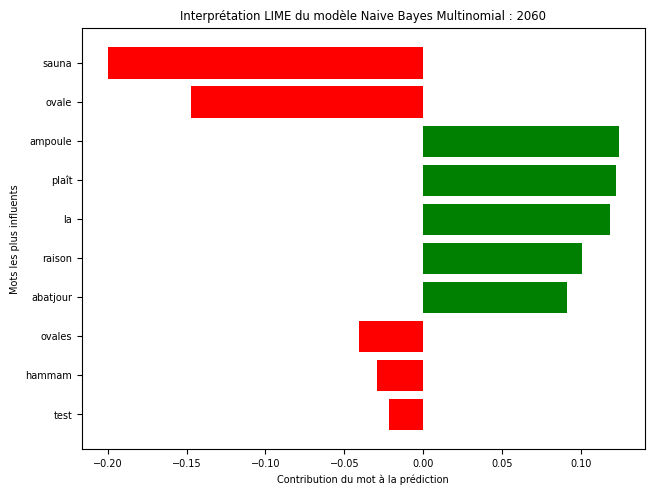

In [ ]:
# Initialisation de LIME pour les explications du modèle Naive Bayes Multinomial optimisé

def predict_proba_text(texts): # Fonction de prédiction de probabilité pour LIME, adaptée au format d'entrée de LIME
    return gs_nb.predict_proba(tfidf.transform(texts))

# Récupération des noms de classes pour LIME
class_names = le.classes_.astype(str).tolist() # Récupération des noms de classes à partir du LabelEncoder pour LIME
explainer = LimeTextExplainer(class_names=class_names) # Initialisation de LIME avec les noms de classes

idx = 0 # Index du texte à expliquer dans l'ensemble de test
texte_a_expliquer = X_test.iloc[idx] # Récupération du texte à expliquer à partir de l'ensemble de test

# Explication de la prédiction pour le texte sélectionné
exp = explainer.explain_instance(
    texte_a_expliquer,
    predict_proba_text,
    num_features=10,
    top_labels=1
)

pred_class = gs_nb.predict(tfidf.transform([texte_a_expliquer]))[0] # Prédiction de la classe pour le texte sélectionné
pred_label = le.inverse_transform([pred_class])[0] # Récupération du nom de la classe prédite à partir de l'index de classe

# Affichage de l'explication LIME pour la classe prédite
fig = exp.as_pyplot_figure(label=pred_class)
plt.title(f"Interprétation LIME du modèle Naive Bayes Multinomial : {pred_label}")
plt.tight_layout()
plt.xlabel("Contribution du mot à la prédiction")
plt.ylabel("Mots les plus influents")
plt.savefig("../reports/figures/lime_NB_interpretation.png", dpi=150, bbox_inches="tight")
plt.show()